In [40]:
import cupy as cp
import math
import matplotlib.pyplot as plt
from model.network import Network

## Loading the Data

In [41]:
training_path = "input/training.txt"
validation_path = "input/validation.txt"

with open(training_path, "r", encoding="utf-8") as file:
    training_data = file.read()

with open(validation_path, "r", encoding="utf-8") as file:
    validation_data = file.read()

training_data = list(training_data)
validation_data = list(validation_data)

x_train = training_data[:-1]
y_train = training_data[1:]

x_test = validation_data[:-1]
y_test = validation_data[1:]

print(f"Training data length: X={len(x_train)}, Y={len(y_train)}")
print(f"Validation data length: X={len(x_test)}, Y={len(y_test)}")

Training data length: X=880791, Y=880791
Validation data length: X=234596, Y=234596


In [42]:
vocabulary = sorted(set(training_data).union(set(validation_data)))
print(f"Vocabulary size: {len(vocabulary)}")

Vocabulary size: 65


In [43]:
def char_to_index(char: str) -> int:
    return vocabulary.index(char)

def index_to_char(index: int) -> str:
    return vocabulary[index]

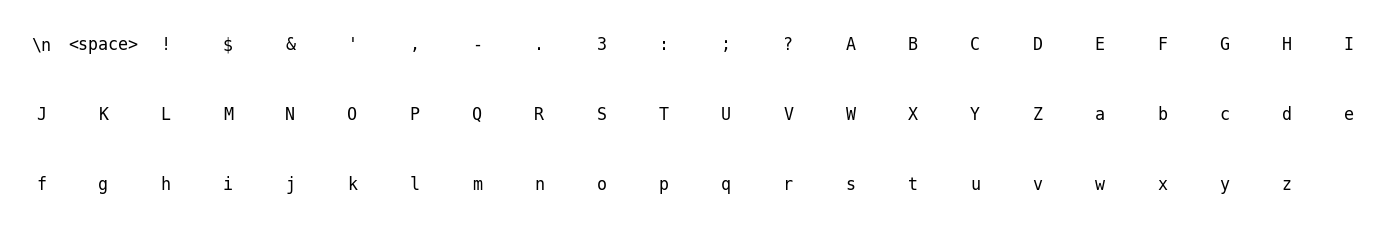

In [44]:
cols = 22
rows = math.ceil(len(vocabulary) / cols)

fig, ax = plt.subplots(figsize=(14, max(2, rows * 0.8)))

for index, token in enumerate(vocabulary):
    row, col = divmod(index, cols)
    display_token = {" ": "<space>", "\n": "\\n", "\t": "\\t"}.get(token, token)
    y = rows - row - 1
    ax.text(col, y, display_token, ha="center", va="center", fontsize=12, family="monospace")

ax.set_xlim(-0.5, cols - 0.5)
ax.set_ylim(-0.5, rows - 0.5)
ax.set_xticks(range(cols))
ax.set_yticks(range(rows))
ax.grid(True, linestyle=":", alpha=0.3)
plt.axis("off")
plt.tight_layout()
plt.show()

In [45]:
x_train_indices = cp.asarray([char_to_index(char) for char in x_train], dtype=cp.int32)
y_train_indices = cp.asarray([char_to_index(char) for char in y_train], dtype=cp.int32)
x_test_indices = cp.asarray([char_to_index(char) for char in x_test], dtype=cp.int32)
y_test_indices = cp.asarray([char_to_index(char) for char in y_test], dtype=cp.int32)

## Building the Model

In [46]:
embedding_dim = 64
hidden_size = 512
hidden_2_size = 256

layer_definitions = [
    {"type": "Embedding", "num_embeddings": len(vocabulary), "embedding_dim": embedding_dim},
    {"type": "Recurrent", "input_size": embedding_dim, "num_neurons": hidden_size},
    {"type": "Dropout", "rate": 0.2},
    {"type": "Recurrent", "input_size": hidden_size, "num_neurons": hidden_2_size},
    {"type": "Dropout", "rate": 0.2},
    {"type": "Softmax", "input_size": hidden_2_size, "num_neurons": len(vocabulary)},
]

network = Network(layer_definitions=layer_definitions)
network.describe()


Network Architecture

Layer 1: EmbeddingLayer
  Embeddings Shape: (65, 64)
  Parameters: 4,160

Layer 2: RecurrentLayer
  Weights Shape: (64, 512) | State Weights Shape: (512, 512) | Biases Shape: (512,)
  Parameters: 295,424

Layer 3: DropoutLayer
  Rate: 0.2

Layer 4: RecurrentLayer
  Weights Shape: (512, 256) | State Weights Shape: (256, 256) | Biases Shape: (256,)
  Parameters: 196,864

Layer 5: DropoutLayer
  Rate: 0.2

Layer 6: SoftmaxLayer
  Weights Shape: (256, 65) | Biases Shape: (65,)
  Parameters: 16,705

Total Parameters: 513,153


## Training the Model

In [47]:
def one_hot(indices: cp.ndarray, num_classes: int) -> cp.ndarray:
    encoded = cp.zeros((indices.shape[0], num_classes), dtype=cp.float32)
    encoded[cp.arange(indices.shape[0]), indices] = 1.0
    return encoded

In [48]:
def reshape_streams(
    x_indices: cp.ndarray,
    y_indices: cp.ndarray,
    batch_size: int,
    max_columns: int | None = None,
 ) -> tuple[cp.ndarray, cp.ndarray]:
    usable_tokens = (x_indices.shape[0] // batch_size) * batch_size
    x = x_indices[:usable_tokens].reshape(batch_size, -1)
    y = y_indices[:usable_tokens].reshape(batch_size, -1)

    if max_columns is not None:
        x = x[:, :max_columns]
        y = y[:, :max_columns]

    return x, y

In [49]:
def evaluate(
    network: Network,
    x_indices: cp.ndarray,
    y_indices: cp.ndarray,
    batch_size: int,
    sequence_length: int,
    max_steps: int | None = None,
) -> float:
    x, y = reshape_streams(
        x_indices=x_indices,
        y_indices=y_indices,
        batch_size=batch_size,
        max_columns=max_steps,
    )

    network.reset_states(batch_size=batch_size, dtype=cp.float32)
    total_loss = 0.0
    total_steps = x.shape[1]

    for step in range(total_steps):
        y_prob = network.forward(x[:, step])[-1]
        y_true = one_hot(y[:, step], len(vocabulary))
        total_loss += float(network.cce_loss(y_prob, y_true).item())

        if (step + 1) % sequence_length == 0:
            network.reset_states(batch_size=batch_size, dtype=cp.float32)

    return math.exp(total_loss / total_steps)


In [50]:
def train_epoch(
    network: Network,
    x_indices: cp.ndarray,
    y_indices: cp.ndarray,
    batch_size: int,
    sequence_length: int,
    learning_rate: float,
    max_steps: int | None = None,
    weight_decay_lambda: float = 0.0,
    momentum: float = 0.0,
    clip_value: float | None = None,
) -> float:
    network.set_training(True)
    x, y = reshape_streams(
        x_indices=x_indices,
        y_indices=y_indices,
        batch_size=batch_size,
        max_columns=max_steps,
    )
    network.reset_states(batch_size=batch_size, dtype=cp.float32)
    total_loss = 0.0
    total_steps = x.shape[1]

    for chunk_start in range(0, total_steps, sequence_length):
        chunk_end = min(chunk_start + sequence_length, total_steps)
        output_errors = []

        for step in range(chunk_start, chunk_end):
            y_prob = network.forward(x[:, step])[-1]
            y_true = one_hot(y[:, step], len(vocabulary))
            total_loss += float(network.cce_loss(y_prob, y_true).item())
            output_errors.append(y_prob - y_true)

        network.backward_sequence(output_errors, batch_size, clip_value=clip_value)
        network.update_parameters(learning_rate, weight_decay_lambda, momentum)
        network.reset_states(batch_size=batch_size, dtype=cp.float32)

    network.set_training(False)
    return math.exp(total_loss / total_steps)


In [51]:
hyperparameters = {
    "sequence_length": 64,
    "batch_size": 64,
    "epochs": 500,
    "train_steps_per_epoch": x_train_indices.shape[0],
    "validation_steps": x_test_indices.shape[0],
    "base_learning_rate": 0.05,
    "min_learning_rate": 0.0005,
    "weight_decay_lambda": 5e-4,
    "momentum": 0.9,
    "early_stopping_patience": 10,
    "clip_value": 5.0,
}

print(hyperparameters)

{'sequence_length': 64, 'batch_size': 64, 'epochs': 500, 'train_steps_per_epoch': 880791, 'validation_steps': 234596, 'base_learning_rate': 0.05, 'min_learning_rate': 0.0005, 'weight_decay_lambda': 0.0005, 'momentum': 0.9, 'early_stopping_patience': 10, 'clip_value': 5.0}


In [52]:
epoch_summaries = []

total_steps = hyperparameters["epochs"] * hyperparameters["train_steps_per_epoch"]
global_step = 0

best_model = None
best_perplexity = float("inf")
epochs_without_improvement = 0

for epoch in range(1, hyperparameters["epochs"] + 1):
    learning_rate = hyperparameters["min_learning_rate"] + 0.5 * (hyperparameters["base_learning_rate"] - hyperparameters["min_learning_rate"]) * (1 + math.cos(math.pi * global_step / total_steps))

    train_perplexity = train_epoch(
        network=network,
        x_indices=x_train_indices,
        y_indices=y_train_indices,
        batch_size=hyperparameters["batch_size"],
        sequence_length=hyperparameters["sequence_length"],
        learning_rate=learning_rate,
        max_steps=hyperparameters["train_steps_per_epoch"],
        weight_decay_lambda=hyperparameters["weight_decay_lambda"],
        momentum=hyperparameters["momentum"],
        clip_value=hyperparameters["clip_value"],
    )
    test_perplexity = evaluate(
        network=network,
        x_indices=x_test_indices,
        y_indices=y_test_indices,
        batch_size=hyperparameters["batch_size"],
        sequence_length=hyperparameters["sequence_length"],
        max_steps=hyperparameters["validation_steps"],
    )

    epoch_summary = {
        "epoch": epoch,
        "learning_rate": learning_rate,
        "train_perplexity": train_perplexity,
        "test_perplexity": test_perplexity,
        "regularization": train_perplexity / test_perplexity,
    }
    epoch_summaries.append(epoch_summary)

    print(epoch_summary)

    if test_perplexity < best_perplexity:
        best_perplexity = test_perplexity
        best_model = network.clone()
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    global_step += hyperparameters["train_steps_per_epoch"]

    if epochs_without_improvement >= hyperparameters["early_stopping_patience"]:
        print(f"Early stopping triggered after {epoch} epochs due to no improvement.")
        break

{'epoch': 1, 'learning_rate': 0.05, 'train_perplexity': 9.829988210189665, 'test_perplexity': 6.897410526295553, 'regularization': 1.4251708192101964}
{'epoch': 2, 'learning_rate': 0.049999511456189395, 'train_perplexity': 7.168222190255434, 'test_perplexity': 6.1860520676828825, 'regularization': 1.1587717193173326}
{'epoch': 3, 'learning_rate': 0.04999804584404446, 'train_perplexity': 6.587402758476618, 'test_perplexity': 5.841412096201277, 'regularization': 1.1277072478348968}
{'epoch': 4, 'learning_rate': 0.049995603221425024, 'train_perplexity': 6.270943790544409, 'test_perplexity': 5.635909085411005, 'regularization': 1.1126765346121785}
{'epoch': 5, 'learning_rate': 0.049992183684761674, 'train_perplexity': 6.049799446504443, 'test_perplexity': 5.4812122863976755, 'regularization': 1.1037338330277389}
{'epoch': 6, 'learning_rate': 0.04998778736905186, 'train_perplexity': 5.891794016836174, 'test_perplexity': 5.364736066638157, 'regularization': 1.0982448984723867}
{'epoch': 7, '

In [53]:
print(f"Best validation perplexity: {best_perplexity:.4f} at epoch {epoch - hyperparameters['early_stopping_patience']}")

Best validation perplexity: 4.0907 at epoch 490


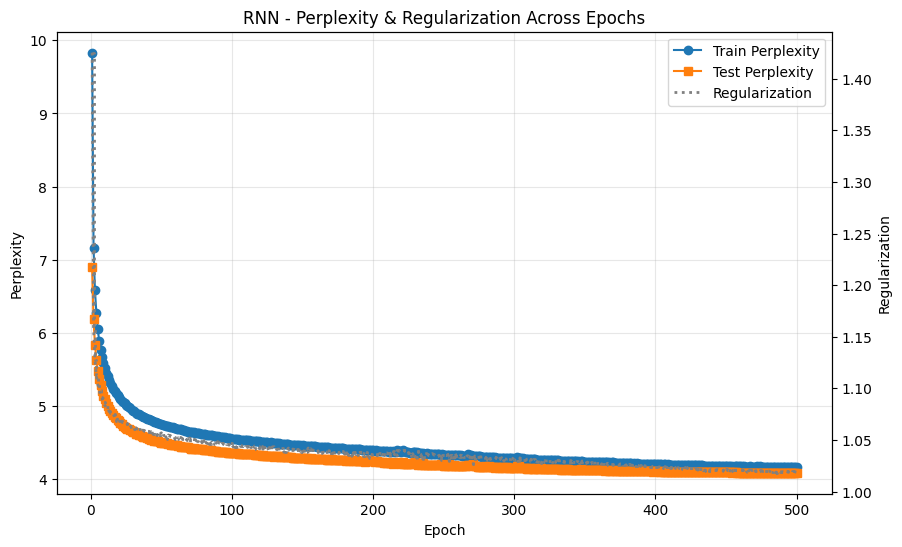

In [ ]:
epochs_plot = [summary["epoch"] for summary in epoch_summaries]
train_perplexities = [summary["train_perplexity"] for summary in epoch_summaries]
test_perplexities = [summary["test_perplexity"] for summary in epoch_summaries]
regularizations = [summary["regularization"] for summary in epoch_summaries]

fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.plot(epochs_plot, train_perplexities, marker="o", label="Train Perplexity")
ax1.plot(epochs_plot, test_perplexities, marker="s", label="Test Perplexity")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Perplexity")
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(epochs_plot, regularizations, color="gray", linestyle=":", linewidth=2, label="Regularization")
ax2.set_ylim(0, max(regularizations) * 1.2)
ax2.set_ylabel("Regularization")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2)

plt.title("RNN - Perplexity & Regularization Across Epochs")
plt.show()

In [55]:
def generate_text(
    network: Network,
    seed_text: str,
    length: int = 250,
    temperature: float = 0.8,
    print_during: bool = True,
) -> str:
    network.reset_states(batch_size=1, dtype=cp.float32)
    generated = list(seed_text)

    if print_during:
        print(seed_text, end="")

    for character in seed_text:
        token_index = cp.asarray([char_to_index(character)], dtype=cp.int32)
        network.forward(token_index)

    current_character = seed_text[-1]

    for _ in range(length):
        token_index = cp.asarray([char_to_index(current_character)], dtype=cp.int32)
        y_prob = network.forward(token_index)[-1][0]
        log_prob = cp.log(y_prob + 1e-9) / temperature
        scaled_prob = cp.exp(log_prob - cp.max(log_prob))
        scaled_prob = scaled_prob / cp.sum(scaled_prob)
        next_index = int(
            cp.random.choice(len(vocabulary), size=1, p=scaled_prob)[0].item()
        )
        current_character = index_to_char(next_index)
        generated.append(current_character)

        if print_during:
            print(current_character, end="", flush=True)

    return "".join(generated)

In [56]:
seed_text = "DANIEL"
generated = generate_text(network=network, seed_text=seed_text, length=1000, temperature=0.85, print_during=True)

DANIELU:
I have not both tim braved accossion: you shall ruth as all.

KING RICHARD III:
O' the tark, mine guilt, chaste, both to him,
his prison'd mad, with a soldier to the crodders?

EDWARD:
What's the morning that an hours he cannot there received these
day the kins and triumnater to them!
Now would the soul is till the Englong Shall you call me
Your doy's revengely, peen our face,
With her comping endied you himself and heart,
And done to deposed thy crown,
And get King of earth on mine own.

GLOUCESTER:
Single not, kenceation, more come:
No, my lord, my lord.
But strust for your popforton as such a father;
For which do them say, I may study your springs, sir,
Most dreams, noy in the sought woe that I will sir, sir,
That have a prison thou may be seen.

VOLUCIO:
The mind is hand than a haust than you thou?

QUEEN MARGARET:
I may never beauty fearing merition.
I know not then?
Lavensed my battless issue of his choolest prince,
And pation as faerer with his instruction;
And he she w

In [57]:
seed_text = "DANIEL"
generated = generate_text(network=network, seed_text=seed_text, length=1000, temperature=0.8, print_during=True)

DANIEL:
Then in those thoughts had consty by this twing bears
And so discords, you will not not to remember thee here.

First Murderer:
Which, between upon his poliing to such rest.

BRUTUS:
Hin father you had an furno as it shall be gone and countered
To see he stones, in the better than the hard-sworn.

BIANCA:
I'll say the husband shall be supposed in him,
To any a more and his man be better then:
He shall be sends, till from me who
best besore I then to the instruction to the hand,
That pound, do hear the boot hear him,
That I be brought of bind by this parted sir;
And thou wert they proclaim our pleased,
You, say, the wrongs be not flow-speept. Rurse, my and victure!

LUCENTIO:
What, aad then, a stortel forth with that I had,
And not rather but a troef their time who for the bawd'st thee;
Your royal hearce gives a weeping man;
And I were larks were on my welcomes? What, as you in
propucether, or all unto your mands,
To tale ear omptiently under the man.

CLARENCE:
Well, thou empte

In [58]:
seed_text = "DANIEL"
generated = generate_text(network=network, seed_text=seed_text, length=1000, temperature=0.75, print_during=True)

DANIEL:
Hortensio! why, think thou canst a magation,
The sea and grant my soul.

LADY GREY:
What this sads are heart!
Far oft rest it for what met the day.

DUKE VINCENTIO:
Come, were one than his old man o' the cowns for this for father;
For you speak of trieg, commons and prays be your sousin's cause,
I should make good to his son, and in the fault!

BENVOLIO:
The sun and made so seef a king, and beauty.

LUCENTIO:
So say, madam again! and to a false on all the seasant,
So be the cloudly consent have the gods be mock
For both for boy on mine father;
No lord on my end.

CORIOLANUS:
Though I do fast I sim,
That thou seefter shame, and break the wornd.

First Citigent:
What, make you on the moke that is the sin
That you have well, but what he is my honour'd larp.

CAPULET:
And, perform your wid; bear me less here.

AUFIDIUS:
The Duke of Grumio;
And for the selson how now a charge them were,
We shall we must not be park the common.

GRUMLO:
We are so stup and blood of him.

ANGELO:
The p

In [59]:
seed_text = "DANIEL"
generated = generate_text(network=network, seed_text=seed_text, length=1000, temperature=0.7, print_during=True)

DANIEL:
What shall that, what, how all at
the steel, that should be my child.

KING RICHARD IIO:
All off they be the people, with my septry son.

MERCUTIO:
My lord, you bear, a seements by water! the king is a drow
As my love, and stright all the purp them at the sumpless
With the heart beseech you and the king, and make me like in the ronging,
Better in our trusty and fortune and of what,
The day bands of his holds--
Ill my country, and the lebs and nokents, sir,
Which cast in the world, the foilory should not fall
The good seement hamblike men,
Let these seass of discounsel, or so let your worthy shall not stutt
Even compate to thy field.

CAPULET:
Sir, the mishand enemies to me.

GLOUCESTER:
I have so judge, and he that will call thee then.

POLIXENES:
'Tis perform, we'll get a duke,
Which should not cell a child.

GLOUCESTER:
Party Clarence! who made remedies
Of the princes of My lord.

Provost:
Away, thou didst none.

CLAUUT:
O, so have we have fuant your share and gentleman,
Wher